In [20]:
from google.colab import files
uploaded = files.upload()

Saving data.csv.zip to data.csv (1).zip


In [21]:
import pandas as pd
import zipfile
import io
import os

# Get the name of the uploaded zip file
zip_file_name = next(iter(uploaded)) # Assuming 'uploaded' dictionary from previous cell

# Unzip the file and read the content
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
    # Get the name of the CSV file inside the zip archive
    # Assuming there's only one CSV file or we want the first one ending with .csv
    csv_files_in_zip = [name for name in z.namelist() if name.endswith('.csv')]
    if not csv_files_in_zip:
        raise ValueError("No CSV file found inside the zip archive.")

    csv_file_name_to_read = csv_files_in_zip[0]

    z.extractall() # Extracts all files to the current directory

df = pd.read_csv(csv_file_name_to_read, low_memory=False)
df.head()

,Unnamed: 0,hhcode,gender1,gender2,gender3,gender4,gender5,gender6,gender7,gender8,...,longtermrainfallshifts2,longtermrainfallshifts3,adjtempshifts1_1,adjtempshifts2_1,adjtempshifts3_1,adjrainfallshifts1_1,adjrainfallshifts2_1,adjrainfallshifts3_1,interviewer,vname
0,0,10010601,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.
1,1,10010602,1.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.
2,2,10010603,2.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.
3,3,10010604,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.
4,4,10010605,1.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.


In [22]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9597 entries, 0 to 9596
Columns: 1754 entries, Unnamed: 0 to vname
dtypes: float64(1576), int64(5), object(173)
memory usage: 128.4+ MB


,Unnamed: 0,hhcode,gender1,gender2,gender3,gender4,gender5,gender6,gender7,gender8,...,ad7616,ad7617,ad7618,ad7619,ad7620,ad7621,ad7622,ad7623,ad7625,longtermrainfallshifts3
count,9597.000000,9.597000e+03,8799.00000,8578.000000,8301.000000,7824.000000,6926.000000,5697.000000,4436.000000,3382.000000,...,6403.000000,6411.000000,6572.000000,6405.000000,6514.000000,6476.000000,6403.000000,6401.000000,6587.000000,0.0
mean,4798.000000,5.085130e+07,1.07660,1.788995,1.449584,1.450665,1.485273,1.502896,1.538774,1.530751,...,-0.009839,0.015286,0.094796,-0.010304,0.089346,0.089098,0.070904,0.027339,0.255048,NaN
std,2770.559601,2.862039e+07,0.26597,0.408046,0.497482,0.497592,0.574047,0.509771,0.498551,0.499127,...,1.239538,1.248806,1.261920,1.239152,1.265469,1.268909,1.269755,1.254381,1.301236,NaN
min,0.000000,1.001060e+07,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,NaN
25%,2399.000000,2.806043e+07,1.00000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,4798.000000,5.004011e+07,1.00000,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,7197.000000,8.002082e+07,1.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
max,9596.000000,1.000901e+08,2.00000,2.000000,2.000000,2.000000,25.000000,9.000000,2.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN


In [23]:
df = df.dropna()           # remove missing values
df = df.drop_duplicates()  # remove duplicates

In [24]:
import pandas as pd

# Reload the original CSV file to get the columns before any data cleaning operations.
# The csv_file_name_to_read variable holds the name of the extracted csv file.
original_df = pd.read_csv(csv_file_name_to_read, low_memory=False)
print("Columns in the original DataFrame:")
for col in original_df.columns:
    print(col)

Columns in the original DataFrame:
Unnamed: 0
hhcode
gender1
gender2
gender3
gender4
gender5
gender6
gender7
gender8
age1
age2
age3
age4
age5
age6
age7
age8
educ1
educ2
educ3
educ4
educ5
educ6
educ7
educ8
married1
married2
married3
married4
married5
married6
married7
married8
farmwork1
farmwork2
farmwork3
farmwork4
farmwork5
farmwork6
farmwork7
farmwork8
nfarmwork1
nfarmwork2
nfarmwork3
nfarmwork4
nfarmwork5
nfarmwork6
nfarmwork7
nfarmwork8
age9
age10
age11
age12
age13
age14
age15
age16
age17
age18
age19
age20
age21
age22
age23
age24
age25
age26
age27
age28
age29
age30
age31
age32
age33
age34
age35
age36
age37
age38
educ9
educ10
educ11
educ12
educ13
educ14
educ15
educ16
educ17
educ18
educ19
educ20
educ21
educ22
educ23
educ24
educ25
educ26
educ27
educ28
educ29
educ30
educ31
educ32
educ33
educ34
educ35
educ36
educ37
educ38
farmwork9
farmwork10
farmwork11
farmwork12
farmwork13
farmwork14
farmwork15
farmwork16
farmwork17
farmwork18
farmwork19
farmwork20
farmwork21
farmwork22
farmwork23
far

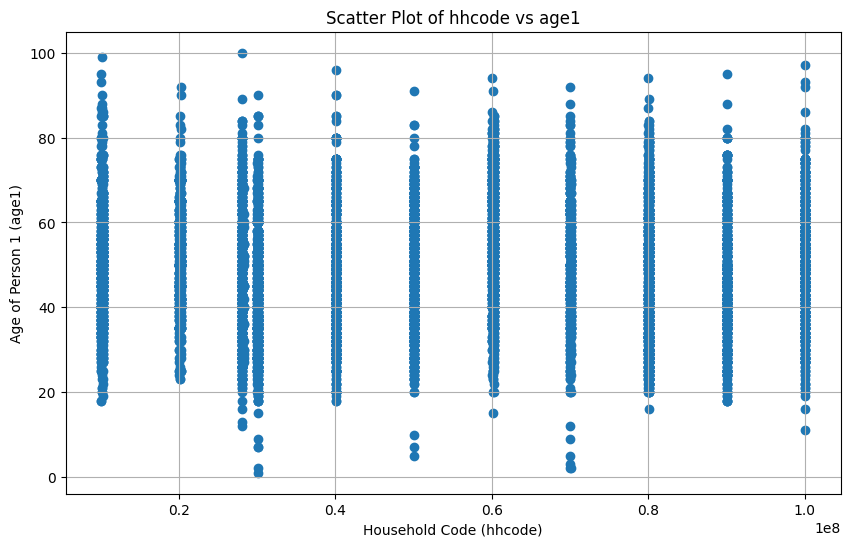

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(original_df['hhcode'], original_df['age1'])
plt.xlabel('Household Code (hhcode)')
plt.ylabel('Age of Person 1 (age1)')
plt.title('Scatter Plot of hhcode vs age1')
plt.grid(True)
plt.show()

<Axes: xlabel='gender1'>

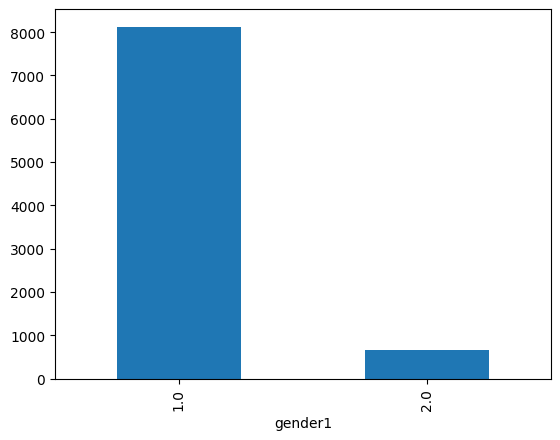

In [26]:
original_df['gender1'].value_counts().plot(kind='bar')

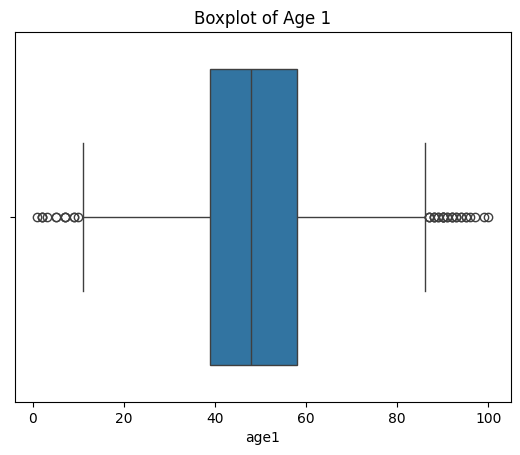

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using original_df because df is empty, and using 'age1' as a valid column example
sns.boxplot(x=original_df['age1'])
plt.title('Boxplot of Age 1')
plt.show()

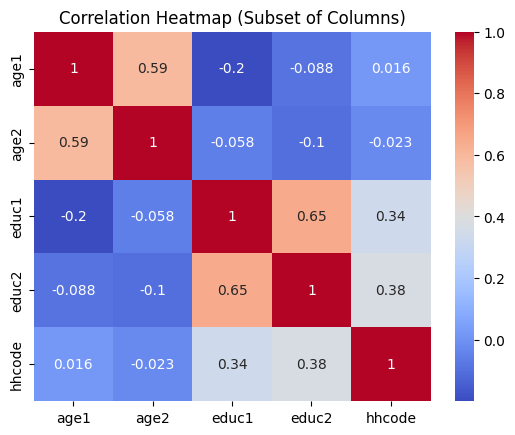

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select a small subset of numeric columns for a readable heatmap
subset_cols = ['age1', 'age2', 'educ1', 'educ2', 'hhcode']
correlation_matrix = original_df[subset_cols].corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Subset of Columns)')
plt.show()